In [42]:
import numpy as np 
import requests
import matplotlib.pyplot as plt

In [43]:
r = requests.get('https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt')
with open("Summary_table.txt", 'wb') as f:
    f.write(r.content)

# Read content
data = np.loadtxt("Summary_table.txt", dtype='str',unpack='True')

# Read headers
with open("Summary_table.txt",'r') as f:
    names = np.array([n.strip().replace(" ","_") for n in f.readlines()[1].replace("#","").replace("\n","").lstrip().split('    ') if n.strip()!=''])

names

array(['GRB_name', 'GRB_name_Fermi', 'T0', 'ra', 'decl', 'pos_error',
       'T90', 'T90_error', 'T90_start', 'fluence', 'fluence_error',
       'redshift', "'T100'", 'GBM_located', 'mjd_(T0)'], dtype='<U14')

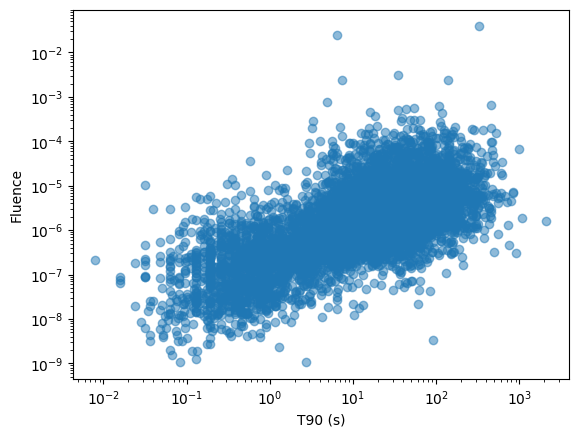

In [44]:
t = data[names=='T90']
f = data[names=='fluence']

flux= np.float64(f[(f!='-999') & (t!='-999')])
time= np.float64(t[(f!='-999') & (t!='-999')])

plt.scatter(time,flux, alpha=0.5)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('T90 (s)')
plt.ylabel('Fluence')
plt.show()

### K_MEANS with two clusters

Text(0.5, 1.0, 'Clustering output')

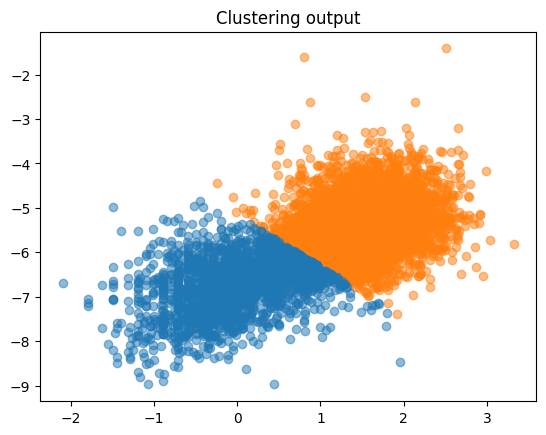

In [45]:
from sklearn.cluster import KMeans
from sklearn import preprocessing

#x has to be [n_samples, n_features]
X = np.vstack([np.log10(time[(time!=0) & (flux!=0)]), np.log10(flux[(time!=0) & (flux!=0)])]).T

clf = KMeans(n_clusters=2,n_init='auto')                #Try 2 clusters to start with
clf.fit(X)
centers = clf.cluster_centers_      #location of the clusters
labels =  clf.predict(X) #labels for each of the points

# plot the data color-coded by cluster id
colors = ['C1', 'C0']
for ii in range(2):
    plt.scatter(X[labels==ii,0], X[labels==ii,1], 
                color=colors[ii],alpha=0.5)

plt.title('Clustering output')

In [46]:
# Compute the Mean-shift clustering
from sklearn.cluster import MeanShift

scaler = preprocessing.StandardScaler()
bandwidth = 1.3 
ms = MeanShift(bandwidth=bandwidth, bin_seeding=False, cluster_all=True)
ms.fit(scaler.fit_transform(X))

MeanShift(bandwidth=1.3)

In [47]:
labels_unique = np.unique(ms.labels_)
n_clusters = len(labels_unique[labels_unique >= 0])
print(labels_unique)
print(bandwidth)
print("number of estimated clusters :", n_clusters)

[0 1]
1.3
number of estimated clusters : 2


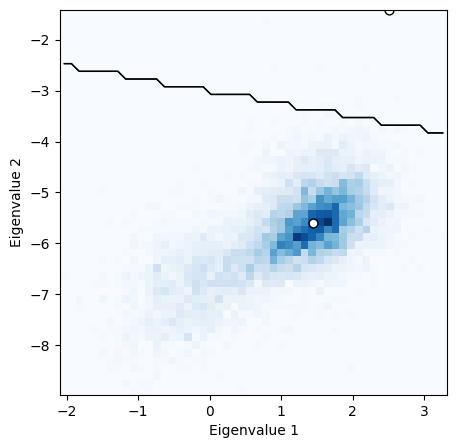

In [48]:
# Make some plots
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot()

# Compute a 2D histogram  of the input
H, xedges, yedges = np.histogram2d(X[:,0], X[:,1], 50)

# plot density
ax.imshow(H.T, origin='lower', interpolation='nearest', aspect='auto',
          extent=[xedges[0], xedges[-1],
                  yedges[0], yedges[-1]],
          cmap='Blues')

# plot cluster centers
cluster_centers = scaler.inverse_transform(ms.cluster_centers_)
ax.scatter(cluster_centers[:, 0], cluster_centers[:, 1],
           s=40, c='w', edgecolors='k')

# plot cluster boundaries
x_centers = 0.5 * (xedges[1:] + xedges[:-1])
y_centers = 0.5 * (yedges[1:] + yedges[:-1])

Xgrid = np.meshgrid(x_centers, y_centers)
Xgrid = np.array(Xgrid).reshape((2, 50 * 50)).T

H = ms.predict(scaler.transform(Xgrid)).reshape((50, 50))

for i in range(n_clusters):
    Hcp = H.copy()
    flag = (Hcp == i)
    Hcp[flag] = 1
    Hcp[~flag] = 0

    ax.contour(x_centers, y_centers, Hcp, [-0.5, 0.5],
               linewidths=1, colors='k')
 
    H = ms.predict(scaler.transform(Xgrid)).reshape((50, 50))
    
ax.set_xlim(xedges[0], xedges[-1])
ax.set_ylim(yedges[0], yedges[-1])

ax.set_xlabel('Eigenvalue 1')
ax.set_ylabel('Eigenvalue 2')

plt.show()

It seems to be not the best algorithm in this case

### Let's focus in time (they are called SHORT and LONG gamma ray burts)

In [49]:
grb=dict(zip(names,data))
for lab in ['T90',"redshift","T90_error"]:
    grb[lab] = np.array(grb[lab],dtype='float')

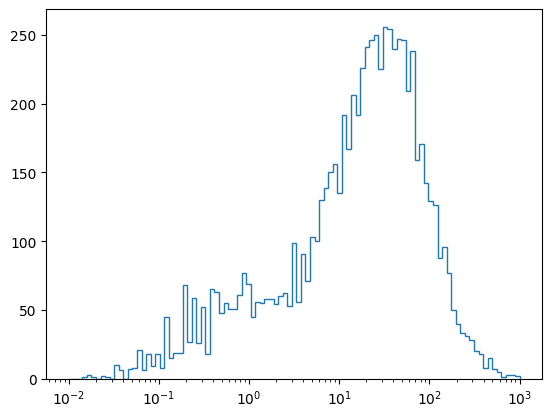

In [50]:
plt.hist(grb['T90'],bins= np.logspace(-2,3,100), histtype='step');
plt.semilogx();

In [ ]:
lT90 = np.log10(grb['T90'][grb['T90']> 0]) #log10 of T90, only positive values
lT90=lT90[~np.isnan(lT90)] 
skT90 = lT90[:,np.newaxis]

### CROSS VALIDATION in order to fin the best KDE width

In [148]:
from sklearn.neighbors import KernelDensity

xgrid=np.logspace(-3,3,100)

def kde_sklearn(data, bandwidth = 1.0):
    kde = KernelDensity(kernel='gaussian', bandwidth=bandwidth).fit(data) #fit the model to the data
    log_pdf = kde.score_samples(np.log10(xgrid)[:, np.newaxis]) # sklearn returns log(density)
    return np.exp(log_pdf)

from sklearn.model_selection import GridSearchCV

bwrange = np.linspace(0.01,2.0, 10) 

K = 5 # Do 5-fold cross validation

grid = GridSearchCV(KernelDensity(), {'bandwidth': bwrange}, cv= K) # Try each bandwidth with K-folds
grid.fit(skT90) #Fit the histogram data that we started the lecture with.
h_opt = grid.best_params_['bandwidth']
print(h_opt)

0.23111111111111113


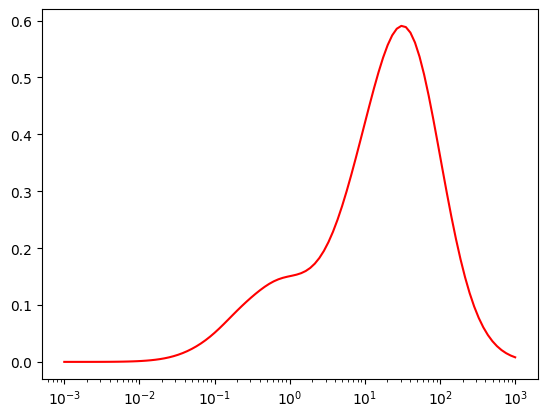

In [149]:
pdf = kde_sklearn(skT90,h_opt)
plt.plot(xgrid,pdf,c='red')
plt.semilogx();

### There are two modes: we can separate them using K-MEANS or MEAN SHIFTING

#### K_MEANS

In [150]:
# We try with 2 modes
clf = KMeans(n_clusters=2, n_init='auto') 
clf.fit(skT90)

KMeans(n_clusters=2)

In [151]:
centers = clf.cluster_centers_
centers = 10**np.squeeze(centers)
centers #in seconds

array([ 0.87789067, 32.65652838])

Prediction for each sample

In [152]:
labels = clf.predict(skT90)

#if the first center is larger than the second, we reverse the order
if centers[0]>centers[1]:
    centers=centers[::-1] # Reverse array
    labels = np.array(~np.array(labels,dtype='bool'),dtype='int') # Swap 0 <--> 1
centers, labels

(array([ 0.87789067, 32.65652838]),
 array([1, 1, 0, ..., 0, 1, 0], dtype=int32))

They are centroids of the two clusters but we want the edge between the two

5.354997665732452


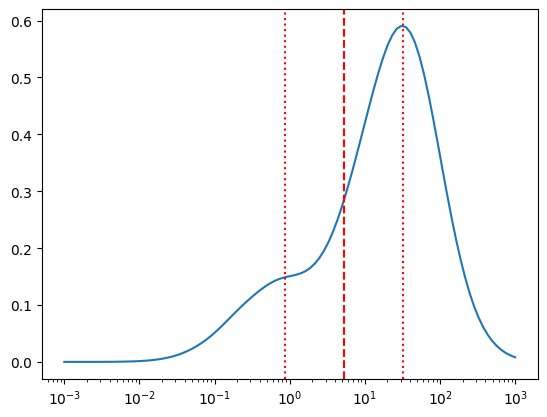

In [153]:
# the mean between the maximum of the first cluster and the minimum of the second cluster
edge = 10**( np.mean( [max(skT90[labels==0]), min(skT90[labels==1]) ]))

print(edge)

plt.plot(xgrid,pdf)
plt.semilogx()
for v in centers:
    plt.axvline(v, c='red',ls='dotted')
plt.axvline(edge,c='red',ls='dashed');

#### MEAN SHIFTING

In [154]:
scaler = preprocessing.StandardScaler()
bandwidth = 0.5
ms = MeanShift(bandwidth=bandwidth, bin_seeding=True, cluster_all=False)
ms.fit(scaler.fit_transform(skT90))

MeanShift(bandwidth=0.5, bin_seeding=True, cluster_all=False)

In [155]:
labels_unique = np.unique(ms.labels_)
n_clusters = len(labels_unique[labels_unique >= 0])
print(labels_unique)
print(bandwidth)
print("number of estimated clusters :", n_clusters)

[-1  0  1]
0.5
number of estimated clusters : 2


[ 0.96254479 31.5992671 ]
[-0.46344156]
[-0.45345734]


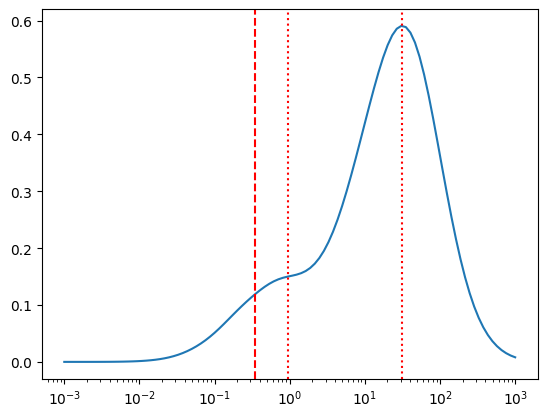

In [156]:
# inverse trasform to find centers in original space
cluster_centers = scaler.inverse_transform(ms.cluster_centers_)
cluster_centers=10**np.squeeze(cluster_centers)

labels2 = ms.predict(skT90)

if cluster_centers[0]>cluster_centers[1]:
    cluster_centers=cluster_centers[::-1] # Reverse array
    labels2 = np.array(~np.array(labels2,dtype='bool'),dtype='int') # Swap 0 <--> 1
cluster_centers, labels2

print(cluster_centers)

edge2 = 10**np.mean([max(skT90[labels2==0]), min(skT90[labels2==1]) ])

print(max(skT90[labels2==0]))
print(min(skT90[labels2==1]))
plt.plot(xgrid,pdf)
plt.semilogx()

for v in cluster_centers:
    plt.axvline(v, c='red',ls='dotted')
plt.axvline(edge2,c='red',ls='dashed');


plt.show()
